In [ ]:
!pip install wget
import wget
wget.download('https://isic-archive.s3.amazonaws.com/challenges/2024/ISIC_2024_Training_Input.zip')
# wget.download('https://isic-archive.s3.amazonaws.com/challenges/2024/ISIC_2024_Training_Supplement.csv')
wget.download('https://isic-archive.s3.amazonaws.com/challenges/2024/ISIC_2024_Training_GroundTruth.csv')
_ = !unzip './ISIC_2024_Training_Input.zip' -d './'

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=a4b7180c9c55edad09298a08a360618b6cfb40eff9bf1de66cfa99115b3ea3dd
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
# Import Necessary Libraries
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

# Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
# MACRO Configurations (Global Variables and Hyperparameters)
# ── Paths ──────────────────────────────────────────────────────────────────
ROOT          = Path(".")
IMAGE_DIR     = ROOT / "ISIC_2024_Training_Input"
GT_CSV        = ROOT / "ISIC_2024_Training_GroundTruth.csv"

# ── Data split ratios ──────────────────────────────────────────────────────
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20   # remaining 0.20 goes to test

# ── Image settings ─────────────────────────────────────────────────────────
IMAGE_SIZE  = 224    # unified input size for both backbones

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT     = 0.4
# NOTE: On Windows in a Jupyter notebook, num_workers > 0 causes worker
# processes to re-import __main__, leading to a spawn deadlock before the
# first batch is served. Keep this at 0 for notebook environments on Windows.
NUM_WORKERS = 0

# ── Optional: use a fraction of data for fast iteration (1.0 = full dataset)
SAMPLE_FRACTION = 1.0


In [ ]:
# Load ground truth CSV
df = pd.read_csv(GT_CSV)
df["malignant"] = df["malignant"].astype(int)

# Keep only rows whose image file actually exists
df["img_path"] = df["isic_id"].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
df = df[df["img_path"].apply(lambda p: p.exists())].reset_index(drop=True)

print(f"Total samples with images: {len(df):,}")
print(f"\nClass distribution:")
print(df["malignant"].value_counts().rename({0: "Benign", 1: "Malignant"}))

# Optional: sub-sample for faster iteration
if SAMPLE_FRACTION < 1.0:
    df = df.groupby("malignant", group_keys=False).apply(
        lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=SEED)
    ).reset_index(drop=True)
    print(f"\nAfter sampling ({SAMPLE_FRACTION:.0%}): {len(df):,} samples")

# ── Class balance plot ────────────────────────────────────────────────────
#fig, ax = plt.subplots(figsize=(5, 4))
#counts = df["malignant"].value_counts().sort_index()
#ax.bar(["Benign (0)", "Malignant (1)"], counts.values, color=["steelblue", "tomato"])
#ax.set_ylabel("Count")
#ax.set_title("Class Distribution")
#for i, v in enumerate(counts.values):
#    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
#plt.tight_layout()
#plt.show()


Total samples with images: 401,059

Class distribution:
malignant
Benign       400666
Malignant       393
Name: count, dtype: int64


In [ ]:
# Define Dataset Class
class SkinLesionDataset(Dataset):
    """
    Loads TBP-cropped lesion images by isic_id and returns
    (image_tensor, label) pairs.
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        label = torch.tensor(row["malignant"], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


# 提取4000个良性，减少训练时间。（之后可以删掉这部分）

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── Step 0: 下采样 (Downsampling) ──────────────────────────────────────────
# 提取所有恶性样本
df_malignant = df[df["malignant"] == 1]
# 随机抽取 4000 个良性样本
df_benign_full = df[df["malignant"] == 0]
df_benign_downsampled = df_benign_full.sample(n=4000, random_state=SEED)

# 合并成新的数据集
df_balanced = pd.concat([df_malignant, df_benign_downsampled]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Downsampling complete:")
print(f"Total samples: {len(df_balanced)} (Benign: 4000, Malignant: {len(df_malignant)})")

# ── Step 1: Stratified Split ──────────────────────────────────────────
# 60% train, 40% temp (用于 val 和 test)
df_train, df_temp = train_test_split(
    df_balanced,
    test_size=(1 - TRAIN_RATIO),
    stratify=df_balanced["malignant"],
    random_state=SEED
)

# Step 2: 50/50 val & test from temp
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp["malignant"],
    random_state=SEED
)

print(f"\nFinal Split Sizes:")
print(f"Train : {len(df_train):>5,} ({df_train['malignant'].sum()} malignant)")
print(f"Val   : {len(df_val):>5,} ({df_val['malignant'].sum()} malignant)")
print(f"Test  : {len(df_test):>5,} ({df_test['malignant'].sum()} malignant)")

# ── Transforms ────────────────────────────────────────────────────────────
# ImageNet normalisation used by both DenseNet and EfficientNet pretrained weights
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

# ── Step 2: Datasets & Sampler ─────────────────────────────────────────
# 数据增强部分保持你原来的 train_transform 和 eval_transform 不变
train_dataset = SkinLesionDataset(df_train, transform=train_transform)
val_dataset   = SkinLesionDataset(df_val,   transform=eval_transform)
test_dataset  = SkinLesionDataset(df_test,  transform=eval_transform)

# ── Weighted sampler to handle class imbalance in training ─────────────────
n_benign    = (df_train["malignant"] == 0).sum()
n_malignant = (df_train["malignant"] == 1).sum()
class_weights = {0: 1.0 / n_benign, 1: 1.0 / n_malignant}
sample_weights = df_train["malignant"].map(class_weights).values
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)


# ── Step 3: DataLoaders ────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True
)
# Val 和 Test 不需要 sampler
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

Downsampling complete:
Total samples: 4393 (Benign: 4000, Malignant: 393)

Final Split Sizes:
Train : 2,635 (236 malignant)
Val   :   879 (78 malignant)
Test  :   879 (79 malignant)


In [ ]:
# Define Hybrid CNN Model
class HybridDenseNetEfficientNet(nn.Module):
    """
    Hybrid CNN:
      - DenseNet-121  → fine-grained texture features (1024-d)
      - EfficientNet-B4 → multi-scale pattern features  (1792-d)
    Features are concatenated then fed into a fusion classifier.
    """

    # Output feature dimensions of the chosen backbone variants
    _DENSENET_OUT    = 1024
    _EFFICIENTNET_OUT = 1792

    def __init__(self, dropout: float = DROPOUT, freeze_backbones: bool = False):
        super().__init__()

        # ── DenseNet-121 backbone ──────────────────────────────────────────
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet_features = densenet.features        # conv layers
        self.densenet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # ── EfficientNet-B4 backbone ───────────────────────────────────────
        efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        self.efficientnet_features = efficientnet.features
        self.efficientnet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # ── Optional backbone freezing (for initial warm-up) ────────
        if freeze_backbones:
            for param in self.densenet_features.parameters():
                param.requires_grad = False
            for param in self.efficientnet_features.parameters():
                param.requires_grad = False

        # ── Fusion classifier ─────────────────────────────────────────────
        combined_dim = self._DENSENET_OUT + self._EFFICIENTNET_OUT  # 2816 total output dim
        # Classifier after the combined model
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(combined_dim),
            nn.Dropout(dropout),
            nn.Linear(combined_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1),   # raw logit for BCEWithLogitsLoss
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # DenseNet branch
        d = self.densenet_features(x)
        d = self.densenet_pool(d)
        d = torch.flatten(d, 1)                          # (B, 1024)

        # EfficientNet branch
        e = self.efficientnet_features(x)
        e = self.efficientnet_pool(e)
        e = torch.flatten(e, 1)                          # (B, 1792)

        # Feature fusion → classification
        fused = torch.cat([d, e], dim=1)                 # (B, 2816)
        return self.classifier(fused).squeeze(1)         # (B,)


# ── Instantiate & inspect ─────────────────────────────────────────────────
model = HybridDenseNetEfficientNet(dropout=DROPOUT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters    : 25,950,921
Trainable parameters: 25,950,921


# 只需运行一个模型，然后训练验证。使用其他模型要重新训练验证

In [ ]:
#baseline 1: ResNet50，经典的模型
class ResNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feats, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)


model = ResNetBaseline().to(DEVICE)

In [ ]:
#baseline 2: DenseNet-121，混合模型之一，查看混合前的效果
class DenseNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        in_feats = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_feats, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)


model = DenseNetBaseline().to(DEVICE)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 73.7MB/s]


In [ ]:
#baseline 3: EfficientNet-B4，混合模型之二，查看混合前的效果
class EfficientNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT, inplace=True),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(1)


model = EfficientNetBaseline().to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 153MB/s]


In [ ]:

# ── Loss: pos_weight compensates for class imbalance ─────────────────────
pos_weight = torch.tensor([n_benign / n_malignant], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Optimiser: AdamW with weight decay ────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── LR scheduler: cosine annealing over all epochs ────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── Mixed-precision scaler (only on GPU) ─────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"pos_weight for BCEWithLogitsLoss: {pos_weight.item():.2f}")


pos_weight for BCEWithLogitsLoss: 10.17


/tmp/ipykernel_604/244692834.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [ ]:
# Define the training loop function
def run_epoch(model, loader, criterion, optimizer=None, scaler=None,
              device=DEVICE, desc=""):
    """
    Run one epoch of training or evaluation.
    When optimizer is None, runs in eval mode (no gradient updates).
    Returns: (avg_loss, auc_roc)
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss   = 0.0
    running_loss = 0.0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(images)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            batch_loss    = loss.item()
            total_loss   += batch_loss * images.size(0)
            running_loss  = total_loss / ((batch_idx + 1) * images.size(0))

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix(loss=f"{running_loss:.4f}")

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc

In [ ]:
# ── Training loop with early stopping ────────────────────────────────────
PATIENCE  = 5
CKPT_PATH = "best_model.pth"

history = {"train_loss": [], "train_auc": [], "val_loss": [], "val_auc": []}
best_val_auc = 0.0
patience_ctr = 0

epoch_pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs",
                  bar_format="{l_bar}{bar:20}{r_bar}")

for epoch in epoch_pbar:
    tr_loss, tr_auc = run_epoch(
        model, train_loader, criterion, optimizer, scaler,
        desc=f"  Train [{epoch}/{NUM_EPOCHS}]"
    )
    vl_loss, vl_auc = run_epoch(
        model, val_loader, criterion,
        desc=f"  Val   [{epoch}/{NUM_EPOCHS}]"
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_auc"].append(tr_auc)
    history["val_loss"].append(vl_loss)
    history["val_auc"].append(vl_auc)

    improved = vl_auc > best_val_auc
    if improved:
        best_val_auc = vl_auc
        patience_ctr = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " *best*"
    else:
        patience_ctr += 1
        tag = f" (patience {patience_ctr}/{PATIENCE})"

    # Update outer bar with latest metrics
    epoch_pbar.set_postfix(
        tr_loss=f"{tr_loss:.4f}", tr_auc=f"{tr_auc:.4f}",
        vl_loss=f"{vl_loss:.4f}", vl_auc=f"{vl_auc:.4f}"
    )
    # Also print a summary line that persists after each epoch
    tqdm.write(
        f"Epoch {epoch:>3}/{NUM_EPOCHS} | "
        f"Train  loss={tr_loss:.4f}  AUC={tr_auc:.4f} | "
        f"Val    loss={vl_loss:.4f}  AUC={vl_auc:.4f}{tag}"
    )

    if patience_ctr >= PATIENCE:
        tqdm.write(f"\nEarly stopping triggered after {epoch} epochs.")
        break

tqdm.write(f"\nBest validation AUC: {best_val_auc:.4f}  (checkpoint: {CKPT_PATH})")


Epochs:   0%|                    | 0/20 [00:00<?, ?it/s]

  Train [1/20]:   0%|                              | 0/83 [00:00<?, ?it/s]

  Val   [1/20]:   0%|                              | 0/28 [00:00<?, ?it/s]

Epoch   1/20 | Train  loss=2.3439  AUC=0.5184 | Val    loss=2.1473  AUC=0.7126 *best*


  Train [2/20]:   0%|                              | 0/83 [00:00<?, ?it/s]

...

  Val   [17/20]:   0%|                              | 0/28 [00:00<?, ?it/s]

Epoch  17/20 | Train  loss=0.7601  AUC=0.9468 | Val    loss=0.7182  AUC=0.9054 (patience 4/5)


  Train [18/20]:   0%|                              | 0/83 [00:00<?, ?it/s]

  Val   [18/20]:   0%|                              | 0/28 [00:00<?, ?it/s]

Epoch  18/20 | Train  loss=0.7923  AUC=0.9438 | Val    loss=0.7183  AUC=0.9062 (patience 5/5)

Early stopping triggered after 18 epochs.

Best validation AUC: 0.9079  (checkpoint: best_model.pth)


           TEST SET RESULTS
  AUC-ROC  : 0.9383
  Accuracy : 0.8237
  F1 Score : 0.4816

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.81      0.89       800
   Malignant       0.33      0.91      0.48        79

    accuracy                           0.82       879
   macro avg       0.66      0.86      0.69       879
weighted avg       0.93      0.82      0.86       879



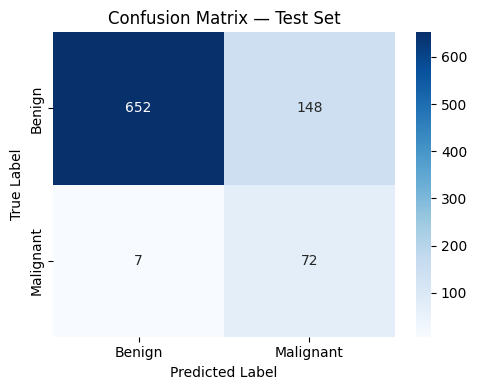

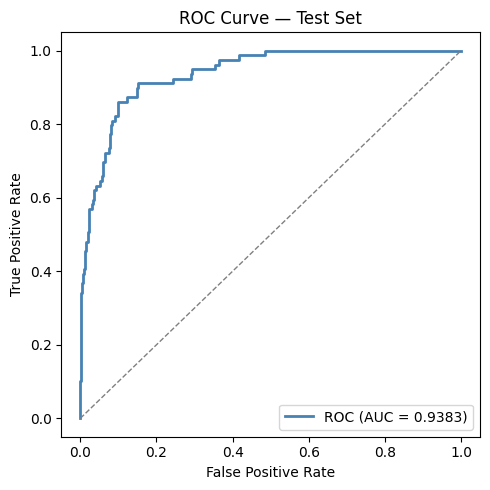

In [ ]:
#HybridDenseNetEfficientNet
# Evaluate using the best model trained
# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions on the test set ──────────────────────────────────
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)

print("=" * 50)
print("           TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=ax)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


           TEST SET RESULTS
  AUC-ROC  : 0.9102
  Accuracy : 0.8703
  F1 Score : 0.5366

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.87      0.92       800
   Malignant       0.40      0.84      0.54        79

    accuracy                           0.87       879
   macro avg       0.69      0.85      0.73       879
weighted avg       0.93      0.87      0.89       879



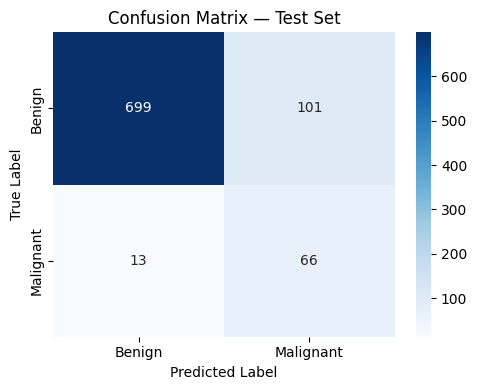

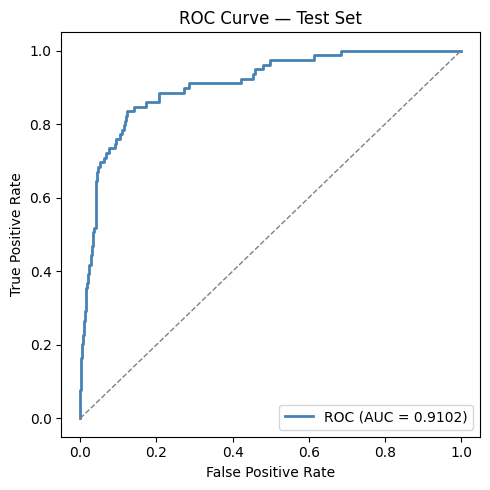

In [ ]:
#ResNet50
# Evaluate using the best model trained
# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions on the test set ──────────────────────────────────
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)

print("=" * 50)
print("           TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=ax)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


           TEST SET RESULTS
  AUC-ROC  : 0.9336
  Accuracy : 0.8771
  F1 Score : 0.5500

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.88      0.93       800
   Malignant       0.41      0.84      0.55        79

    accuracy                           0.88       879
   macro avg       0.70      0.86      0.74       879
weighted avg       0.93      0.88      0.89       879



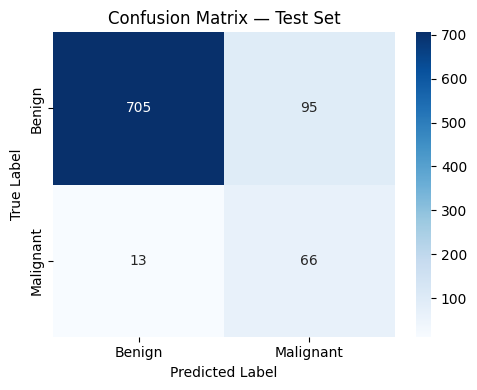

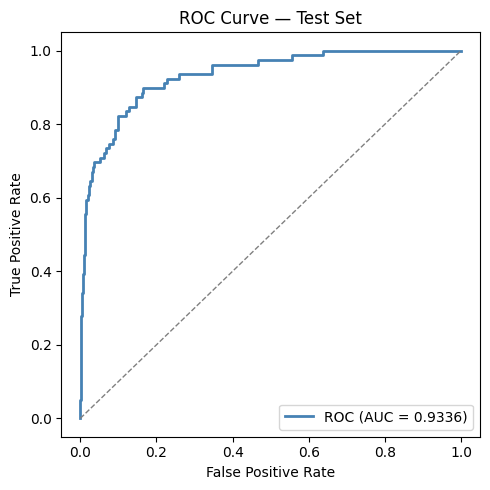

In [ ]:
#DenseNet
# Evaluate using the best model trained
# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions on the test set ──────────────────────────────────
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)

print("=" * 50)
print("           TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=ax)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
#EfficientNet
# Evaluate using the best model trained
# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions on the test set ──────────────────────────────────
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)

print("=" * 50)
print("           TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=ax)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


           TEST SET RESULTS
  AUC-ROC  : 0.9284
  Accuracy : 0.7941
  F1 Score : 0.4396

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.78      0.87       800
   Malignant       0.29      0.90      0.44        79

    accuracy                           0.79       879
   macro avg       0.64      0.84      0.66       879
weighted avg       0.92      0.79      0.83       879

